In [1]:
!pip install tf-levenberg-marquardt 

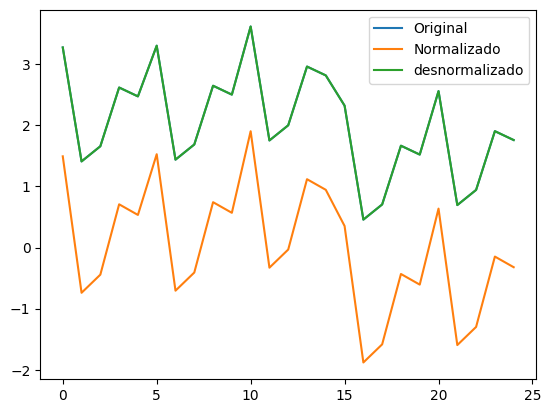

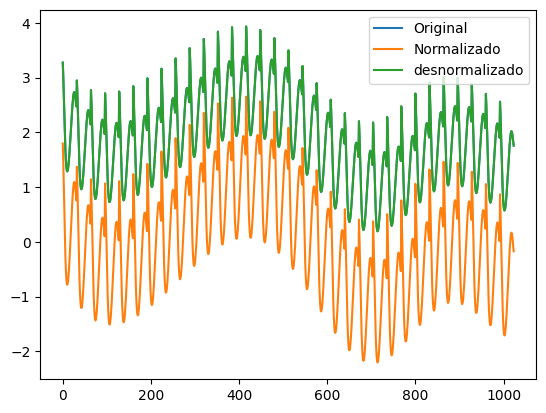

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def function(grid): 
    x = np.linspace(1, 0, grid)
    y = np.linspace(1, 0, grid)
    x, y = np.meshgrid(x, y)
    z = 1.3356 * (1.5 * (1 - x))+np.exp(2 * x - 1) * np.sin(3 * np.pi * (x - 0.6)**2)+np.exp(3*(y - 0.5)) * np.sin(4 * np.pi * (y - 0.9)**2)
    return x, y, z

def create_dataframe(grid):
   x, y, z = function(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-06-08 15:07:31.560543: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-08 15:07:31.749552: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-08 15:07:31.749595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-08 15:07:31.753103: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-08 15:07:31.767006: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-08 15:07:31.767949: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.6,
            hidden_sizes = [[7, 8], [8, 7], [8, 8], [8, 6], [8, 5], [6, 8], [8, 6]],
            regularizers=[0.5, 0.3],
            learning_rate=[0.1, 0.5])

Testando combinacao1: Hidden Size=[7, 8], regularizer=0.5, learning_rate=0.1


+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 8ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 8ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 9ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 7ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 8ms/step
+++++++++++ [1_0] | 9 ++++++++++++++++++
Stopped at epoch:  6
32/32 [===========

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_14,0.532931,0.310254,-0.749298,-2.357641,-0.933860,0.277272,0.409463,1.019724,0.618772,0.819248,0.123492,0.526566,1.160138,0.548983,190.565511,305.139839
model_1_0_13,0.532547,0.310215,-0.728521,-2.310213,-0.909249,0.277500,0.409486,1.007612,0.610031,0.808822,0.127217,0.526783,1.160270,0.549209,190.563866,305.138194
model_1_0_15,0.532594,0.309724,-0.768223,-2.402336,-0.956602,0.277472,0.409778,1.030755,0.627008,0.828882,0.120917,0.526757,1.160254,0.549182,190.564067,305.138395
model_1_0_12,0.531131,0.309395,-0.705879,-2.260811,-0.882926,0.278341,0.409973,0.994413,0.600927,0.797670,0.131492,0.527580,1.160755,0.550040,190.557818,305.132146
model_1_0_16,0.531763,0.308787,-0.785376,-2.443896,-0.977444,0.277966,0.410334,1.040755,0.634667,0.837711,0.118592,0.527225,1.160539,0.549670,190.560513,305.134841
model_1_0_17,0.530613,0.307580,-0.800840,-2.482116,-0.996396,0.278649,0.411051,1.049769,0.641711,0.845740,0.116489,0.527872,1.160933,0.550344,190.555607,305.129935
model_1_0_11,0.528312,0.307548,-0.681292,-2.210333,-0.855030,0.280014,0.411070,0.980081,0.591625,0.785853,0.136256,0.529164,1.161722,0.551691,190.545830,305.120157
model_1_0_18,0.529266,0.306199,-0.814743,-2.517011,-1.013551,0.279448,0.411870,1.057873,0.648142,0.853007,0.114585,0.528628,1.161394,0.551133,190.549879,305.124207
model_1_0_19,0.527816,0.304723,-0.827204,-2.548693,-1.029016,0.280309,0.412747,1.065138,0.653980,0.859559,0.112860,0.529442,1.161892,0.551982,190.543725,305.118053
model_1_0_10,0.523620,0.304375,-0.654680,-2.159981,-0.825769,0.282800,0.412953,0.964568,0.582345,0.773457,0.141571,0.531789,1.163330,0.554429,190.526032,305.100360


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  14
32/32 [==============================] - 0s 12ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 7ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_1] | 9 +++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_24,0.985258,0.711629,0.940382,0.953752,0.962414,0.008752,0.171189,0.034604,0.018970,0.026787,0.037563,0.093550,1.005054,0.097532,197.477042,312.051369
model_1_1_23,0.985045,0.711209,0.939766,0.953337,0.962043,0.008878,0.171439,0.034962,0.019140,0.027051,0.037852,0.094224,1.005128,0.098235,197.448317,312.022644
model_1_1_22,0.984795,0.710732,0.939052,0.952881,0.961621,0.009026,0.171722,0.035376,0.019327,0.027352,0.038169,0.095007,1.005213,0.099052,197.415210,311.989538
model_1_1_21,0.984502,0.710189,0.938225,0.952379,0.961140,0.009200,0.172044,0.035857,0.019533,0.027695,0.038515,0.095918,1.005314,0.100002,197.377038,311.951365
model_1_1_20,0.984157,0.709571,0.937262,0.951829,0.960589,0.009405,0.172411,0.036416,0.019759,0.028087,0.038892,0.096979,1.005432,0.101108,197.333031,311.907359
model_1_1_19,0.983750,0.708866,0.936138,0.951225,0.959958,0.009647,0.172830,0.037068,0.020006,0.028537,0.039301,0.098217,1.005571,0.102398,197.282312,311.856640
model_1_1_18,0.983268,0.708062,0.934824,0.950562,0.959232,0.009933,0.173307,0.037831,0.020278,0.029055,0.039744,0.099662,1.005737,0.103905,197.223867,311.798194
model_1_1_17,0.982696,0.707144,0.933278,0.949832,0.958392,0.010272,0.173852,0.038728,0.020578,0.029653,0.040221,0.101353,1.005933,0.105668,197.156571,311.730899
model_1_1_16,0.982014,0.706096,0.931456,0.949028,0.957419,0.010678,0.174474,0.039786,0.020908,0.030347,0.040732,0.103332,1.006167,0.107731,197.079231,311.653559
model_1_1_15,0.981195,0.704895,0.929289,0.948129,0.956278,0.011163,0.175187,0.041043,0.021276,0.031160,0.041276,0.105656,1.006447,0.110154,196.990271,311.564598


...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 5ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_0,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_22,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_21,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_20,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_19,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_18,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_17,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_16,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_15,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_8_14,0.99947,0.688907,0.998627,0.999553,0.999233,0.000314,0.184678,0.000816,0.000499,0.000657,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 1s 16ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 8ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 4ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  0
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_0,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_22,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_21,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_20,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_19,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_18,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_17,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_16,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_15,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988
model_28_9_14,0.99947,0.688907,0.998035,0.999998,0.999597,0.000314,0.184678,0.000505,0.000001,0.000253,0.008319,0.017732,1.000208,0.018487,186.129543,289.733988


DataFrame salvo em content/results/metrics_28_9
